In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import trainB4
from trainB4 import UNetPlusPlusWithEfficientNetB4

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = UNetPlusPlusWithEfficientNetB4(num_classes=1, pretrained=False).to(device)
model.load_state_dict(torch.load(r"F:\other\Mining\eff\UNet++backbone\models\UNpp_EN_B4_96.pth", map_location=device, weights_only=True))
model.eval()

def preprocess_image(img, img_width=400, img_height=400):
    """Resize image to model input size and normalize."""
    img = img.convert("RGB")
    img = img.resize((img_width, img_height), Image.BILINEAR)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0)
    return img_tensor.to(device), img_array

def segment_image(img):
    """Predict segmentation mask for an image."""
    img_tensor, img_array = preprocess_image(img)
    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred).cpu().numpy()
        mask = (pred > 0.5).astype(np.uint8)[0, 0]  # Binary mask (400x400)
    return mask, img_array

def predict_image_grids(image_input, model, device, output_mask_path, output_plot_path, grid_rows=3, grid_cols=2, img_width=400, img_height=400):
    """
    Split image into 3x2 grid, predict masks for each cell, reassemble, display, and save.
    
    Args:
        image_input (str or PIL.Image): Path to image or PIL Image object.
        model: Trained segmentation model (UNet++ with EfficientNet-B4).
        device: Torch device (cuda or cpu).
        output_mask_path (str): Path to save reassembled mask (PNG).
        output_plot_path (str): Path to save visualization plot (PNG).
        grid_rows (int): Number of grid rows (default: 3).
        grid_cols (int): Number of grid columns (default: 2).
        img_width (int): Model input width (default: 400).
        img_height (int): Model input height (default: 400).
    
    Returns:
        np.ndarray: Reassembled mask (original image size, binary).
    """
    # Load image
    if isinstance(image_input, str):
        img = Image.open(image_input).convert("RGB")
    else:
        img = image_input.convert("RGB")
    
    # Get original dimensions
    orig_width, orig_height = img.size
    img_array = np.array(img, dtype=np.float32) / 255.0  # Normalize to [0, 1]
    
    # Calculate cell sizes
    cell_height = orig_height // grid_rows
    cell_width = orig_width // grid_cols
    
    # Split into 3x2 grid
    grids = []
    grid_coords = []
    for i in range(grid_rows):
        for j in range(grid_cols):
            y = i * cell_height
            x = j * cell_width
            # Crop cell (handle edges)
            cell = img.crop((x, y, min(x + cell_width, orig_width), min(y + cell_height, orig_height)))
            grids.append(cell)
            grid_coords.append((y, x, min(y + cell_height, orig_height), min(x + cell_width, orig_width)))
    
    # Predict masks for each cell
    masks = []
    with torch.no_grad():
        for cell in grids:
            mask, _ = segment_image(cell)  # Auto-resizes to 400x400
            # Resize mask back to cell size
            cell_img = Image.fromarray((mask * 255).astype(np.uint8))
            cell_width = grid_coords[len(masks)][3] - grid_coords[len(masks)][1]
            cell_height = grid_coords[len(masks)][2] - grid_coords[len(masks)][0]
            mask_resized = np.array(cell_img.resize((cell_width, cell_height), Image.NEAREST)) // 255
            masks.append(mask_resized)
    
    # Reassemble masks
    full_mask = np.zeros((orig_height, orig_width), dtype=np.uint8)
    for mask, (y1, x1, y2, x2) in zip(masks, grid_coords):
        full_mask[y1:y2, x1:x2] = mask
    
    # Visualize
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes[0, 0].imshow(img_array)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis("off")
    
    # Display grid masks (3x2 grid, 6 cells)
    for i, mask in enumerate(masks):
        row = (i // 2) + 1
        col = i % 2
        axes[row, col].imshow(mask, cmap="gray")
        axes[row, col].set_title(f"Cell {i+1} Mask")
        axes[row, col].axis("off")
    
    # Reassembled mask
    axes[1, 2].imshow(full_mask, cmap="gray")
    axes[1, 2].set_title("Reassembled Mask")
    axes[1, 2].axis("off")
    
    # Leave unused subplots empty
    axes[0, 1].axis("off")
    axes[0, 2].axis("off")
    axes[2, 2].axis("off")
    
    plt.tight_layout()
    plt.savefig(output_plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    
    # Save reassembled mask
    mask_img = Image.fromarray(full_mask * 255)  # Scale to [0, 255] for PNG
    mask_img.save(output_mask_path)
    
    return full_mask

# Example usage
image_path = r"F:\other\Mining\eff\report17-4\2019-11-15-00_00_2019-11-15-23_59_Sentinel-2_L2A_True_color.png"
output_mask_path = r"F:\other\Mining\eff\report17-4\outputs\mask_2019.png"
output_plot_path = r"F:\other\Mining\eff\report17-4\outputs\grid_prediction_2019.png"

full_mask = predict_image_grids(image_path, model, device, output_mask_path, output_plot_path)
print(f"Saved reassembled mask to: {output_mask_path}")
print(f"Saved visualization to: {output_plot_path}")

In [12]:
import numpy as np
from PIL import Image
import torch
import cv2
import os
from trainB4 import UNetPlusPlusWithEfficientNetB4


def predict_and_save_patches(image_path, model, grid_size=(3, 2), device='cpu', threshold=0.3, save_dir="outputs"):
    """
    Split image into fixed 3x2 grid, predict and save masks and overlays per patch and full image.
    """
    model.eval()

    # Load image
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image, dtype=np.float32) / 255.0
    H, W, _ = image_np.shape

    rows, cols = grid_size
    h_patch = H // rows
    w_patch = W // cols

    # Create output folders
    os.makedirs(save_dir, exist_ok=True)
    patch_dir = os.path.join(save_dir, "patches")
    os.makedirs(patch_dir, exist_ok=True)

    # Create empty canvas for full image
    full_mask = np.zeros((H, W), dtype=np.uint8)
    full_overlay = np.zeros((H, W, 3), dtype=np.uint8)

    for row in range(rows):
        for col in range(cols):
            y1 = row * h_patch
            x1 = col * w_patch
            y2 = (row + 1) * h_patch if row != rows - 1 else H
            x2 = (col + 1) * w_patch if col != cols - 1 else W

            patch = image_np[y1:y2, x1:x2]

            # Predict
            patch_tensor = torch.from_numpy(patch).permute(2, 0, 1).unsqueeze(0).float().to(device)
            with torch.no_grad():
                pred = model(patch_tensor)
                pred = torch.sigmoid(pred).cpu().numpy()[0, 0]
                mask = (pred > threshold).astype(np.uint8)

            # Overlay
            overlay = patch.copy()
            overlay[mask == 1] = (0.5 * overlay[mask == 1] + 0.5 * np.array([0, 1, 0])).clip(0, 1)
            overlay = (overlay * 255).astype(np.uint8)

            # Save patch mask and overlay
            patch_id = f"r{row+1}_c{col+1}"
            cv2.imwrite(os.path.join(patch_dir, f"patch_mask_{patch_id}.png"), (mask * 255).astype(np.uint8))
            cv2.imwrite(os.path.join(patch_dir, f"patch_overlay_{patch_id}.png"), overlay)

            # Stitch into full image
            full_mask[y1:y2, x1:x2] = mask
            full_overlay[y1:y2, x1:x2] = overlay

    # Save full results
    cv2.imwrite(os.path.join(save_dir, "full_mask.png"), (full_mask * 255).astype(np.uint8))
    cv2.imwrite(os.path.join(save_dir, "full_overlay.png"), full_overlay)

    print(f"✅ Saved full mask and overlay to {save_dir}")
    print(f"✅ Saved patch predictions to {patch_dir}")


if __name__ == "__main__":
    image_path = r"F:\other\Mining\eff\report17-4\2016-11-15-00_00_2016-11-15-23_59_Sentinel-2_L2A_True_color.png"
    model_path = r"F:\other\Mining\eff\UNet++backbone\models\UNpp_EN_B4_96.pth"
    output_dir = "outputs"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Using device: {device}")

    model = UNetPlusPlusWithEfficientNetB4(num_classes=1, pretrained=False).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))

    predict_and_save_patches(
        image_path=image_path,
        model=model,
        grid_size=(3, 2),  # 3 rows x 2 columns = 6 patches
        device=device,
        threshold=0.3,
        save_dir=output_dir
    )


🚀 Using device: cuda


C:\Users\KarimNabel\AppData\Local\Temp\ipykernel_11204\1242486728.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_locat

✅ Saved full mask and overlay to outputs
✅ Saved patch predictions to outputs\patches


In [ ]:
from trainB4 import UNetPlusPlusWithEfficientNetB4
import torch
import cv2

# Ensure CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = UNetPlusPlusWithEfficientNetB4(num_classes=1, pretrained=False)
model.load_state_dict(torch.load(
    r"F:\other\Mining\eff\UNet++backbone\models\UNpp_EN_B4_96.pth",
    map_location=device
))
model.to(device)

# Run prediction
from predict_large_image_grid import predict_large_image_grid  # or paste the function directly
mask, overlay = predict_large_image_grid(
    image_path=r"F:\other\Mining\eff\report17-4\2016-11-15-00_00_2016-11-15-23_59_Sentinel-2_L2A_True_color.png",
    model=model,
    device=device
)

# Save results
cv2.imwrite("highres_mask.png", (mask * 255).astype(np.uint8))
cv2.imwrite("highres_overlay.png", overlay)


In [23]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from trainB4 import UNetPlusPlusWithEfficientNetB4


def preprocess_image(img, size=(600, 600)):
    img = img.convert("RGB")
    img = img.resize(size, Image.BILINEAR)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0)
    return img_tensor.to(device), img_array


def segment_image(img, model, device):
    img_tensor, img_array = preprocess_image(img)
    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred).cpu().numpy()[0, 0]
        mask = (pred > 0.5).astype(np.uint8)

    rgb_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    rgb_mask[mask == 1] = [255, 255, 255]

    overlay = img_array.copy()
    overlay[mask == 1] = (0.4 * overlay[mask == 1] + 0.4 * np.array([0, 1, 0])).clip(0, 1)
    overlay = (overlay * 255).astype(np.uint8)

    return mask, rgb_mask, overlay, img_array


def compute_change_map(mask_t1, mask_t2):
    return mask_t2 - mask_t1


def visualize_change_map(img_t2, change_map):
    alpha = 0.3
    img = img_t2.copy()
    mask_new = (change_map == 1)
    mask_lost = (change_map == -1)
    green = np.array([0, 1, 0])
    red = np.array([1, 0, 0])

    overlay = img.copy()
    overlay[mask_new] = (1 - alpha) * img[mask_new] + alpha * green
    overlay[mask_lost] = (1 - alpha) * img[mask_lost] + alpha * red
    overlay = (overlay * 255).astype(np.uint8)

    change_rgb = np.zeros((*change_map.shape, 3), dtype=np.uint8)
    change_rgb[mask_new] = [0, 255, 0]
    change_rgb[mask_lost] = [255, 0, 0]

    return change_rgb, overlay


def run_change_detection(img_t1_path, img_t2_path, model_path, output_dir="outputs"):
    os.makedirs(output_dir, exist_ok=True)

    # Load model
    model = UNetPlusPlusWithEfficientNetB4(num_classes=1, pretrained=False).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Load and segment both images
    img_t1 = Image.open(img_t1_path)
    img_t2 = Image.open(img_t2_path)

    mask_t1, rgb_mask_t1, overlay_t1, img_arr_t1 = segment_image(img_t1, model, device)
    mask_t2, rgb_mask_t2, overlay_t2, img_arr_t2 = segment_image(img_t2, model, device)

    change_map = compute_change_map(mask_t1, mask_t2)
    change_rgb, overlay_change = visualize_change_map(img_arr_t2, change_map)

    # Save all outputs
    cv2.imwrite(os.path.join(output_dir, "mask_t1.png"), rgb_mask_t1)
    cv2.imwrite(os.path.join(output_dir, "mask_t2.png"), rgb_mask_t2)
    cv2.imwrite(os.path.join(output_dir, "overlay_t1.png"),cv2.cvtColor(overlay_t1, cv2.COLOR_RGB2BGR) )
    cv2.imwrite(os.path.join(output_dir, "overlay_t2.png"),cv2.cvtColor(overlay_t2, cv2.COLOR_RGB2BGR) )
    cv2.imwrite(os.path.join(output_dir, "change_map.png"), cv2.cvtColor(change_rgb, cv2.COLOR_RGB2BGR) )
    cv2.imwrite(os.path.join(output_dir, "overlay_change.png"), overlay_change)

    # ✅ Save only T2 + overlay change map as its own image
    #cv2.imwrite(os.path.join(output_dir, "t2_with_overlay_change.png"), overlay_change)
    cv2.imwrite(os.path.join(output_dir, "t2_with_overlay_change.png"), cv2.cvtColor(overlay_change, cv2.COLOR_RGB2BGR))


    # Save summary plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(change_rgb)
    ax[0].set_title("Change Map")
    ax[0].axis("off")
    ax[1].imshow(overlay_change)
    ax[1].set_title("T2 + Overlay")
    ax[1].axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "change_detection_result.png"), dpi=300)
    plt.close()

    print("✅ All results saved in:", output_dir)


# ========== Entry point ==========
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    run_change_detection(
        img_t1_path=r"F:\other\Mining\eff\report17-4\original\2016-11-15-00_00_2016-11-15-23_59_Sentinel-2_L2A_True_color.png",
        img_t2_path=r"F:\other\Mining\eff\report17-4\original\2019-11-15-00_00_2019-11-15-23_59_Sentinel-2_L2A_True_color.png",
        model_path=r"F:\other\Mining\eff\Deploy\UNpp_EN_B4_96.pth",
        output_dir="outputs"
    )


C:\Users\KarimNabel\AppData\Local\Temp\ipykernel_11204\1098943467.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_locat

✅ All results saved in: outputs


🟩 Total changed pixels: 19081
🌍 Total changed area: 1.5745 km²
🔍 Found 60 change clusters


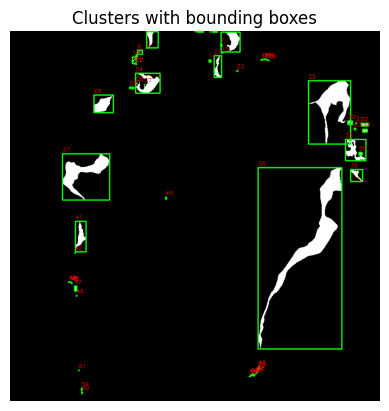

 - Cluster #1 → Area: 0.0002 km²
 - Cluster #2 → Area: 0.0240 km²
 - Cluster #3 → Area: 0.0011 km²
 - Cluster #4 → Area: 0.0001 km²
 - Cluster #5 → Area: 0.0009 km²
 - Cluster #6 → Area: 0.0604 km²
 - Cluster #7 → Area: 0.0005 km²
 - Cluster #8 → Area: 0.0001 km²
 - Cluster #9 → Area: 0.0012 km²
 - Cluster #10 → Area: 0.0003 km²
 - Cluster #11 → Area: 0.0003 km²
 - Cluster #12 → Area: 0.0229 km²
 - Cluster #13 → Area: 0.0021 km²
 - Cluster #14 → Area: 0.0003 km²
 - Cluster #15 → Area: 0.0002 km²
 - Cluster #16 → Area: 0.0002 km²
 - Cluster #17 → Area: 0.0015 km²
 - Cluster #18 → Area: 0.0001 km²
 - Cluster #19 → Area: 0.0001 km²
 - Cluster #20 → Area: 0.0001 km²
 - Cluster #21 → Area: 0.0001 km²
 - Cluster #22 → Area: 0.0001 km²
 - Cluster #23 → Area: 0.0002 km²
 - Cluster #24 → Area: 0.0841 km²
 - Cluster #25 → Area: 0.2960 km²
 - Cluster #26 → Area: 0.0002 km²
 - Cluster #27 → Area: 0.0001 km²
 - Cluster #28 → Area: 0.0012 km²
 - Cluster #29 → Area: 0.0661 km²
 - Cluster #30 → Area: 

In [27]:
import cv2
import numpy as np
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt

def calculate_area_and_clusters(binary_mask, aoi_width_km=8.70, aoi_height_km=6.07, image_size=(800, 800), visualize=False):
    """
    Calculates the area of changed pixels in km² and clusters them.
    Args:
        binary_mask: np.uint8 mask with 1 = changed, 0 = background
        aoi_width_km: real-world AOI width in kilometers
        aoi_height_km: real-world AOI height in kilometers
        image_size: size used in segmentation (default 800x800)
        visualize: whether to show clustered areas with bounding boxes
    Returns:
        total_area_km2, cluster_stats (list of dicts)
    """
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    h, w = image_size
    total_pixels = h * w
    pixel_area_km2 = (aoi_width_km * aoi_height_km) / total_pixels

    # Count total changed pixels
    changed_pixel_count = np.sum(binary_mask)
    total_area_km2 = changed_pixel_count * pixel_area_km2

    print(f"🟩 Total changed pixels: {changed_pixel_count}")
    print(f"🌍 Total changed area: {total_area_km2:.4f} km²")

    # =================== Connected Components ===================
    label_img = label(binary_mask, connectivity=2)
    props = regionprops(label_img)

    cluster_stats = []
    for i, prop in enumerate(props, 1):
        cluster_pixel_count = prop.area
        cluster_area_km2 = cluster_pixel_count * pixel_area_km2
        bbox = prop.bbox  # (min_row, min_col, max_row, max_col)

        cluster_stats.append({
            "cluster_id": i,
            "pixel_count": cluster_pixel_count,
            "area_km2": cluster_area_km2,
            "bbox": bbox
        })

    print(f"🔍 Found {len(cluster_stats)} change clusters")

    if visualize:
        rgb_overlay = np.stack([binary_mask * 255] * 3, axis=-1).astype(np.uint8)
        for c in cluster_stats:
            minr, minc, maxr, maxc = c['bbox']
            cv2.rectangle(rgb_overlay, (minc, minr), (maxc, maxr), (0, 255, 0), 2)
            cv2.putText(rgb_overlay, f"{c['cluster_id']}", (minc, minr-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
        plt.imshow(rgb_overlay)
        plt.title("Clusters with bounding boxes")
        plt.axis("off")
        plt.show()

    return total_area_km2, cluster_stats


# ========== Example Usage ==========
if __name__ == "__main__":
    # Load binary mask (T2 - T1 = change map)
    change_mask = cv2.imread("outputs/2019-2016-800/change_map.png", cv2.IMREAD_GRAYSCALE)
    binary_change = (change_mask > 0).astype(np.uint8)

    total_area_km2, clusters = calculate_area_and_clusters(
        binary_mask=binary_change,
        aoi_width_km=8.70,
        aoi_height_km=6.07,
        image_size=(800, 800),
        visualize=True
    )

    # Optional: print cluster info
    for c in clusters:
        print(f" - Cluster #{c['cluster_id']} → Area: {c['area_km2']:.4f} km²")


In [28]:
import cv2
import numpy as np
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt

def calculate_top4_clusters(binary_mask, aoi_width_km=8.70, aoi_height_km=6.07, image_size=(800, 800), visualize=True):
    """
    Detects the top 4 largest change clusters from a binary mask and calculates their real-world areas.
    """
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    h, w = image_size
    total_pixels = h * w
    pixel_area_km2 = (aoi_width_km * aoi_height_km) / total_pixels

    # Label connected components
    labeled = label(binary_mask, connectivity=2)
    props = regionprops(labeled)

    # Compute area for all clusters
    cluster_stats = []
    for i, prop in enumerate(props, 1):
        pixel_count = prop.area
        area_km2 = pixel_count * pixel_area_km2
        cluster_stats.append({
            "cluster_id": i,
            "pixel_count": pixel_count,
            "area_km2": area_km2,
            "bbox": prop.bbox
        })

    # Sort by area (descending) and keep top 4
    top_clusters = sorted(cluster_stats, key=lambda x: x["area_km2"], reverse=True)[:4]

    # Total area of top 4
    total_top_area = sum([c["area_km2"] for c in top_clusters])
    print(f"✅ Top 4 change area: {total_top_area:.4f} km²")

    if visualize:
        vis_img = np.stack([binary_mask * 255] * 3, axis=-1).astype(np.uint8)
        for c in top_clusters:
            minr, minc, maxr, maxc = c["bbox"]
            cv2.rectangle(vis_img, (minc, minr), (maxc, maxr), (0, 255, 0), 2)
            cv2.putText(vis_img, f"#{c['cluster_id']}", (minc, minr - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
        plt.imshow(vis_img)
        plt.title("Top 4 Change Clusters")
        plt.axis("off")
        plt.show()

    return total_top_area, top_clusters


In [30]:
import numpy as np
import cv2
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def calculate_top6_colored_clusters(binary_mask, aoi_width_km=8.70, aoi_height_km=6.07,
                                     image_size=(800, 800), visualize=True, save_path=None):
    """
    Finds top 6 clusters, assigns unique color, and annotates areas in km².
    """
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    h, w = image_size
    pixel_area_km2 = (aoi_width_km * aoi_height_km) / (h * w)

    labeled = label(binary_mask, connectivity=2)
    props = regionprops(labeled)

    cluster_stats = []
    for i, prop in enumerate(props, 1):
        pixel_count = prop.area
        area_km2 = pixel_count * pixel_area_km2
        cluster_stats.append({
            "cluster_id": i,
            "pixel_count": pixel_count,
            "area_km2": area_km2,
            "bbox": prop.bbox,
            "coords": prop.coords
        })

    # Sort by area and take top 6
    top_clusters = sorted(cluster_stats, key=lambda x: x["area_km2"], reverse=True)[:6]
    total_area_km2 = sum(c["area_km2"] for c in top_clusters)

    print(f"🌍 Total area (top 6 clusters): {total_area_km2:.4f} km²")

    if visualize:
        # Generate blank color image
        color_map = np.zeros((h, w, 3), dtype=np.uint8)

        # Define 6 distinguishable colors (RGB)
        cluster_colors = [
            (255, 0, 0),      # Red
            (0, 255, 0),      # Green
            (0, 0, 255),      # Blue
            (255, 255, 0),    # Yellow
            (255, 0, 255),    # Magenta
            (0, 255, 255)     # Cyan
        ]

        legend_handles = []
        for idx, cluster in enumerate(top_clusters):
            cluster_color = cluster_colors[idx % len(cluster_colors)]
            for coord in cluster["coords"]:
                y, x = coord
                color_map[y, x] = cluster_color
            legend_label = f"#{idx+1} → {cluster['area_km2']:.4f} km²"
            legend_handles.append(mpatches.Patch(color=np.array(cluster_color)/255.0, label=legend_label))

        # Plot with legend
        plt.figure(figsize=(10, 8))
        plt.imshow(color_map)
        plt.title("Top 6 Change Clusters (colored)")
        plt.axis("off")
        plt.legend(handles=legend_handles, loc="upper right", fontsize=10, title="Cluster Areas")
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    return total_area_km2, top_clusters


🌍 Total area (top 6 clusters): 1.3755 km²


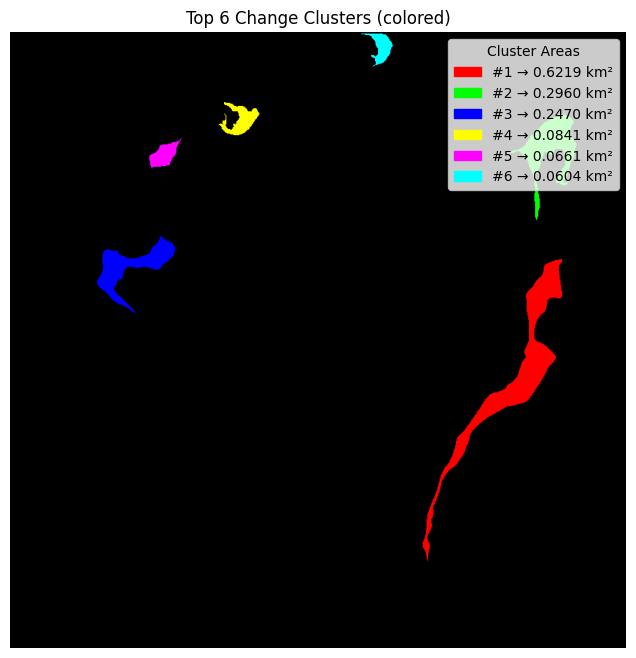

📍 Cluster #38: 0.6219 km² (7537.0 px)
📍 Cluster #25: 0.2960 km² (3587.0 px)
📍 Cluster #37: 0.2470 km² (2994.0 px)
📍 Cluster #24: 0.0841 km² (1019.0 px)
📍 Cluster #29: 0.0661 km² (801.0 px)
📍 Cluster #6: 0.0604 km² (732.0 px)


In [31]:
if __name__ == "__main__":
    # Load binary mask
    mask = cv2.imread("outputs/2019-2016-800/change_map.png", cv2.IMREAD_GRAYSCALE)
    binary = (mask > 0).astype(np.uint8)

    total_area_km2, top6 = calculate_top6_colored_clusters(
        binary_mask=binary,
        aoi_width_km=8.70,
        aoi_height_km=6.07,
        image_size=(800, 800),
        visualize=True,
        save_path="top6_clusters_colored.png"
    )

    for c in top6:
        print(f"📍 Cluster #{c['cluster_id']}: {c['area_km2']:.4f} km² ({c['pixel_count']} px)")


In [34]:
import numpy as np
import cv2
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def calculate_clusters_area_and_visualize(binary_mask, aoi_width_km=8.70, aoi_height_km=6.07,
                                           image_size=(800, 800), visualize=True, save_path=None):
    """
    Calculates total area of all clusters and highlights top 6 largest with color + legend.
    """
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    h, w = image_size
    pixel_area_km2 = (aoi_width_km * aoi_height_km) / (h * w)

    # Connected component labeling
    labeled = label(binary_mask, connectivity=2)
    props = regionprops(labeled)

    all_clusters = []
    for i, prop in enumerate(props, 1):
        px_count = prop.area
        km2 = px_count * pixel_area_km2
        all_clusters.append({
            "cluster_id": i,
            "pixel_count": px_count,
            "area_km2": km2,
            "bbox": prop.bbox,
            "coords": prop.coords
        })

    # Total area of all clusters
    total_all_clusters_area_km2 = sum(c["area_km2"] for c in all_clusters)

    # Top 6 clusters by area
    top_clusters = sorted(all_clusters, key=lambda x: x["area_km2"], reverse=True)[:6]
    total_top6_area_km2 = sum(c["area_km2"] for c in top_clusters)

    print(f"🌍 Total area of ALL clusters: {total_all_clusters_area_km2:.4f} km²")
    print(f"🎯 Total area of TOP 6 clusters: {total_top6_area_km2:.4f} km²")

    # Visualization
    if visualize:
        vis_img = np.stack([binary_mask * 255] * 3, axis=-1).astype(np.uint8)

        # Top 6 distinct colors
        cluster_colors = [
            (255, 0, 0),     # Red
            (0, 255, 0),     # Green
            (0, 0, 255),     # Blue
            (255, 255, 0),   # Yellow
            (255, 0, 255),   # Magenta
            (0, 255, 255)    # Cyan
        ]

        legend = []
        for idx, cluster in enumerate(top_clusters):
            color = cluster_colors[idx % len(cluster_colors)]
            for y, x in cluster["coords"]:
                vis_img[y, x] = color
            label_txt = f"#{idx+1} → {cluster['area_km2']:.4f} km²"
            legend.append(mpatches.Patch(color=np.array(color)/255.0, label=label_txt))

        # Plot with legend below (bottom-left)
        plt.figure(figsize=(10, 8))
        plt.imshow(vis_img)
        plt.title("Top 6 Change Clusters")
        plt.axis("off")

        plt.legend(
            handles=legend,
            loc="upper left",
            bbox_to_anchor=(0.0, -0.1),  # ✅ bottom-left of plot
            borderaxespad=0,
            fontsize=10,
            title="Area per cluster",
            ncol=1,
            frameon=True
        )

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    return {
        "total_area_all_km2": total_all_clusters_area_km2,
        "total_area_top6_km2": total_top6_area_km2,
        "top_6_clusters": top_clusters,
        "all_clusters": all_clusters
    }


🌍 Total area of ALL clusters: 1.5745 km²
🎯 Total area of TOP 6 clusters: 1.3755 km²


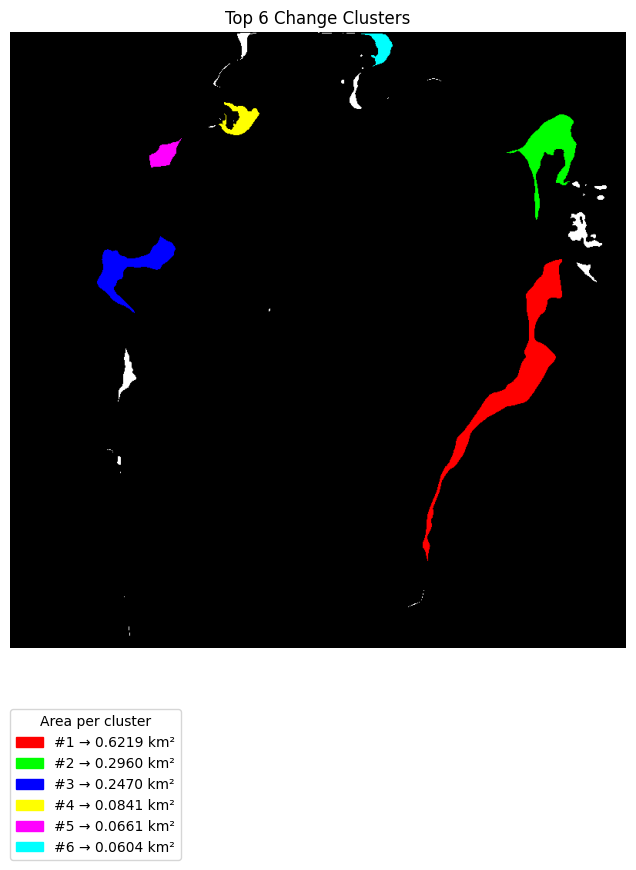


Top 6 Clusters:
📍 Cluster #38: 0.6219 km² (7537.0 px)
📍 Cluster #25: 0.2960 km² (3587.0 px)
📍 Cluster #37: 0.2470 km² (2994.0 px)
📍 Cluster #24: 0.0841 km² (1019.0 px)
📍 Cluster #29: 0.0661 km² (801.0 px)
📍 Cluster #6: 0.0604 km² (732.0 px)

✅ Total area (top 6): 1.3755 km²
✅ Total area (all clusters): 1.5745 km²


In [35]:
if __name__ == "__main__":
    change_mask = cv2.imread("outputs/2019-2016-800/change_map.png", cv2.IMREAD_GRAYSCALE)
    binary = (change_mask > 0).astype(np.uint8)

    result = calculate_clusters_area_and_visualize(
        binary_mask=binary,
        aoi_width_km=8.70,
        aoi_height_km=6.07,
        image_size=(800, 800),
        visualize=True,
        save_path="top6_clusters_colored.png"
    )

    print("\nTop 6 Clusters:")
    for c in result["top_6_clusters"]:
        print(f"📍 Cluster #{c['cluster_id']}: {c['area_km2']:.4f} km² ({c['pixel_count']} px)")

    print(f"\n✅ Total area (top 6): {result['total_area_top6_km2']:.4f} km²")
    print(f"✅ Total area (all clusters): {result['total_area_all_km2']:.4f} km²")


In [43]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.measure import label, regionprops
from trainB4 import UNetPlusPlusWithEfficientNetB4


def preprocess_image(img, size=(600, 600)):
    img = img.convert("RGB")
    img = img.resize(size, Image.BILINEAR)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0)
    return img_tensor.to(device), img_array


def segment_image(img, model, device):
    img_tensor, img_array = preprocess_image(img)
    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred).cpu().numpy()[0, 0]
        mask = (pred > 0.5).astype(np.uint8)

    rgb_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    rgb_mask[mask == 1] = [255, 255, 255]

    overlay = img_array.copy()
    overlay[mask == 1] = (0.4 * overlay[mask == 1] + 0.4 * np.array([0, 1, 0])).clip(0, 1)
    overlay = (overlay * 255).astype(np.uint8)

    return mask, rgb_mask, overlay, img_array


def compute_change_map(mask_t1, mask_t2):
    return mask_t2 - mask_t1


def visualize_change_map(img_t2, change_map):
    alpha = 0.3
    img = img_t2.copy()
    mask_new = (change_map == 1)
    mask_lost = (change_map == -1)
    green = np.array([0, 1, 0])
    red = np.array([1, 0, 0])

    overlay = img.copy()
    overlay[mask_new] = (1 - alpha) * img[mask_new] + alpha * green
    overlay[mask_lost] = (1 - alpha) * img[mask_lost] + alpha * red
    overlay = (overlay * 255).astype(np.uint8)

    change_rgb = np.zeros((*change_map.shape, 3), dtype=np.uint8)
    change_rgb[mask_new] = [0, 255, 0]
    change_rgb[mask_lost] = [255, 0, 0]

    return change_rgb, overlay


def cluster_and_plot_on_overlay(binary_mask, overlay_image, output_path, aoi_width_km=8.7, aoi_height_km=6.07, image_size=(600, 600)):
    h, w = image_size
    pixel_area_km2 = (aoi_width_km * aoi_height_km) / (h * w)

    labeled = label(binary_mask, connectivity=2)
    props = regionprops(labeled)

    all_clusters = []
    for i, prop in enumerate(props, 1):
        px_count = prop.area
        km2 = px_count * pixel_area_km2
        all_clusters.append({
            "cluster_id": i,
            "pixel_count": px_count,
            "area_km2": km2,
            "bbox": prop.bbox,
            "coords": prop.coords
        })

    top_clusters = sorted(all_clusters, key=lambda x: x["area_km2"], reverse=True)[:6]
    total_area_all_km2 = sum(c["area_km2"] for c in all_clusters)
    total_area_top6_km2 = sum(c["area_km2"] for c in top_clusters)

    print(f"✅ Total area (all clusters): {total_area_all_km2:.4f} km²")
    print(f"✅ Total area (top 6): {total_area_top6_km2:.4f} km²")

    # Colors for top clusters
    cluster_colors = [
        (255, 0, 0), (0, 255, 0), (0, 0, 255),
        (255, 255, 0), (255, 0, 255), (0, 255, 255)
    ]

    vis_img = overlay_image.copy()
    legend = []
    for idx, cluster in enumerate(top_clusters):
        color = cluster_colors[idx % len(cluster_colors)]
        for y, x in cluster["coords"]:
            vis_img[y, x] = color
        label_txt = f"#{idx+1} → {cluster['area_km2']:.4f} km²"
        legend.append(mpatches.Patch(color=np.array(color)/255.0, label=label_txt))

    # Add total area as summary patch
    legend.append(mpatches.Patch(color='black', label=f"Total Area: {total_area_all_km2:.4f} km²"))

    plt.figure(figsize=(10, 8))
    plt.imshow(vis_img)
    plt.title("Top Changes")
    plt.axis("off")
    plt.legend(
        handles=legend,
        loc="upper left",
        bbox_to_anchor=(0.0, -0.1),
        borderaxespad=0,
        fontsize=10,
        title="Top Areas",
        ncol=1,
        frameon=True
    )
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


def run_change_detection(img_t1_path, img_t2_path, model_path, output_dir="outputs"):
    os.makedirs(output_dir, exist_ok=True)

    # Load model
    model = UNetPlusPlusWithEfficientNetB4(num_classes=1, pretrained=False).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Load and segment both images
    img_t1 = Image.open(img_t1_path)
    img_t2 = Image.open(img_t2_path)

    mask_t1, rgb_mask_t1, overlay_t1, img_arr_t1 = segment_image(img_t1, model, device)
    mask_t2, rgb_mask_t2, overlay_t2, img_arr_t2 = segment_image(img_t2, model, device)

    change_map = compute_change_map(mask_t1, mask_t2)
    change_rgb, overlay_change = visualize_change_map(img_arr_t2, change_map)

    # Save outputs
    cv2.imwrite(os.path.join(output_dir, "mask_t1.png"), rgb_mask_t1)
    cv2.imwrite(os.path.join(output_dir, "mask_t2.png"), rgb_mask_t2)
    cv2.imwrite(os.path.join(output_dir, "overlay_t1.png"), cv2.cvtColor(overlay_t1, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(output_dir, "overlay_t2.png"), cv2.cvtColor(overlay_t2, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(output_dir, "change_map.png"), cv2.cvtColor(change_rgb, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(output_dir, "overlay_change.png"), cv2.cvtColor(overlay_change, cv2.COLOR_RGB2BGR))

    # Final visual with cluster overlay and legend
    cluster_and_plot_on_overlay(
        binary_mask=(change_map == 1).astype(np.uint8),
        overlay_image=overlay_change,
        output_path=os.path.join(output_dir, "overlay_change_with_clusters.png"),
        aoi_width_km=8.70,
        aoi_height_km=6.07,
        image_size=(600, 600)
    )

    print("✅ All results saved in:", output_dir)




C:\Users\KarimNabel\AppData\Local\Temp\ipykernel_11204\3001375703.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loca

✅ Total area (all clusters): 2.5362 km²
✅ Total area (top 6): 2.4745 km²


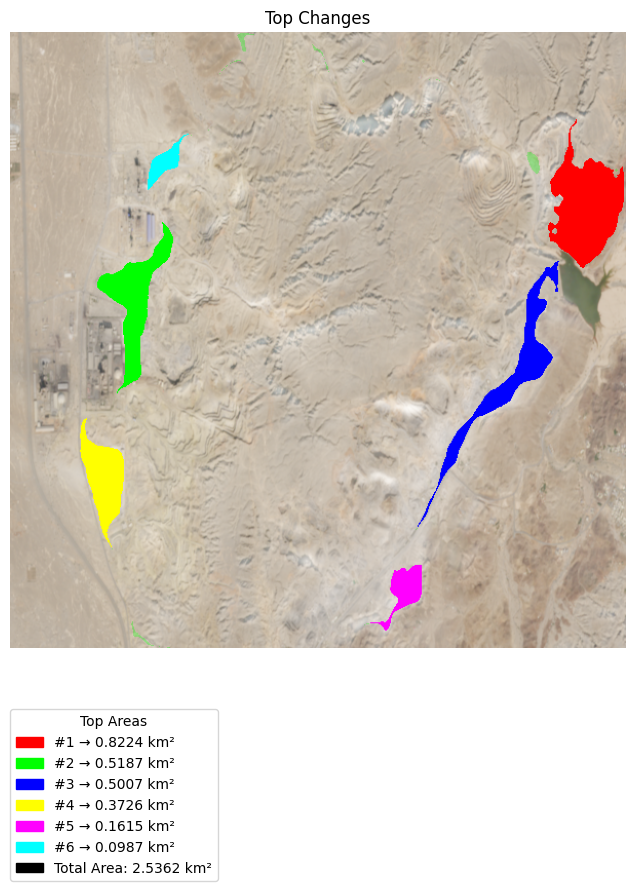

✅ All results saved in: outputs


In [44]:
# ========== Entry point ==========
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    run_change_detection(
        img_t1_path=r"F:\other\Mining\eff\report17-4\original\2016-11-15-00_00_2016-11-15-23_59_Sentinel-2_L2A_True_color.png",
        img_t2_path=r"F:\other\Mining\eff\report17-4\original\2019-11-15-00_00_2019-11-15-23_59_Sentinel-2_L2A_True_color.png",
        model_path=r"F:\other\Mining\eff\Deploy\UNpp_EN_B4_96.pth",
        output_dir="outputs"
    )
